# Calculating a PSF for Roman Wide Field Instrument (WFI)

This demonstration notebook offers a graphical interface to the basic functionality of STPSF-Roman, as well an example of performing a calculation with the Python scripting interface suited for more advanced calculations.

## Background and boilerplate

Before we can do a calculation, we must set up the notebook by importing the packages we use and setting up logging output so we can follow the progress of the calculations. Run the cell below to import STPSF alongside other standard scientific Python tools and configure some options to make plots prettier.

*(Note: click in a cell and use **Shift + Enter** or click the play button <i class="fa-step-forward fa"></i> above to run it)*

In [1]:
%matplotlib inline

import os
os.environ['STPSF_PATH'] = '/Users/jotor/stpsf-data-cyc10/'

import matplotlib
matplotlib.rcParams['figure.figsize'] = (16, 7)  # make the default figure size larger
matplotlib.rcParams['image.interpolation'] = 'nearest'  # don't blur/smooth image plots
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

import numpy as np

import stpsf
import stpsf.roman

The next cell tells STPSF to log information about what it is doing so that we can watch the progress of the calculation:

In [2]:
stpsf.setup_logging()

STPSF log messages of level INFO and above will be shown.
STPSF log outputs will be directed to the screen.


**Note:** As you explore in this notebook, you may see certain warnings that look like this:

<div class="output_subarea output_stderr" style="font-family: monospace; margin: 1em">Warning: something happened! </div>

For the most part, warnings are safe to ignore. In particular, warnings referencing the matplotlib plotting library or the FITS library in Astropy don't indicate anything that could affect the accuracy of the calculations.

# Using the WFI model in STPSF

Each instrument in STPSF is represented as a Python `class`, and the Wide Field Instrument model is in `stpsf.roman.WFI`. We can to instantiate one to work with, in the same was as any of the JWST instruments.

In [3]:
wfi = stpsf.roman.WFI()

[  stpsf] Using pupil mask 'F062' and detector 'WFI01'.


### Calculate PSF
Here we will show a boilerplate monochromatic calculation at the default field position. A more detailed example is presented in the [STPSF-Roman documentation page](https://pythonhosted.org/stpsf/roman.html).

The `wfi.calcPSF()` method returns a [FITS HDUList object](http://docs.astropy.org/en/stable/io/fits/index.html), can be written out to a file or analyzed further in the notebook.

[  poppy] Monochromatic calculation requested.
[  stpsf] Using pupil mask 'F062' and detector 'WFI01'.
[  poppy] PSF calc using fov_arcsec = 5.000000, oversample = 4, number of wavelengths = 1
[  stpsf] Creating optical system model:
[  poppy] Initialized OpticalSystem: Roman+WFI
[  poppy] Roman Entrance Pupil: Loaded amplitude transmission from /Users/jotor/stpsf-data-cyc10/WFI/pupils/RST_WIM_Filter_F062_WFI01.fits.gz
[  poppy] Roman Entrance Pupil: Loaded OPD from /Users/jotor/stpsf-data-cyc10/upscaled_HST_OPD.fits
[  poppy] Added pupil plane: Roman Entrance Pupil
[  poppy] Added coordinate inversion plane: OTE exit pupil
[  poppy] Added pupil plane: Field Dependent Aberration (WFI01)
[  poppy] Added detector with pixelscale=0.1078577405 and oversampling=4: WFI detector
[  poppy] Calculating PSF with 1 wavelengths
[  poppy]  Propagating wavelength = 1.2e-06 m


[  stpsf] Attempted to get aberrations at wavelength 1.2e-06 outside the range of the reference data; clipping to closest wavelength 7.6e-07
[  stpsf] Attempted to get aberrations at wavelength 1.2e-06 outside the range of the reference data; clipping to closest wavelength 7.6e-07
[  stpsf] Attempted to get aberrations at wavelength 1.2e-06 outside the range of the reference data; clipping to closest wavelength 7.6e-07
[  stpsf] Attempted to get aberrations at wavelength 1.2e-06 outside the range of the reference data; clipping to closest wavelength 7.6e-07
[  stpsf] Attempted to get aberrations at wavelength 1.2e-06 outside the range of the reference data; clipping to closest wavelength 7.6e-07


[  poppy]   Calculation completed in 9.510 s
[  poppy] PSF Calculation completed.
[  poppy] Calculating jitter using gaussian
[  poppy] Jitter: Convolving with Gaussian with sigma=0.012 arcsec
[  poppy]         resulting image peak drops to 0.957 of its previous value
[  stpsf] Adding PSF detector effects. add_distortion disabled for Roman.
[  stpsf] Detector charge diffusion: Convolving with Gaussian with sigma=0.000 arcsec
[  poppy]  Adding extension with image downsampled to detector pixel scale.
[  poppy]  Downsampling to detector pixel scale, by 4
[  poppy]  Downsampling to detector pixel scale, by 4


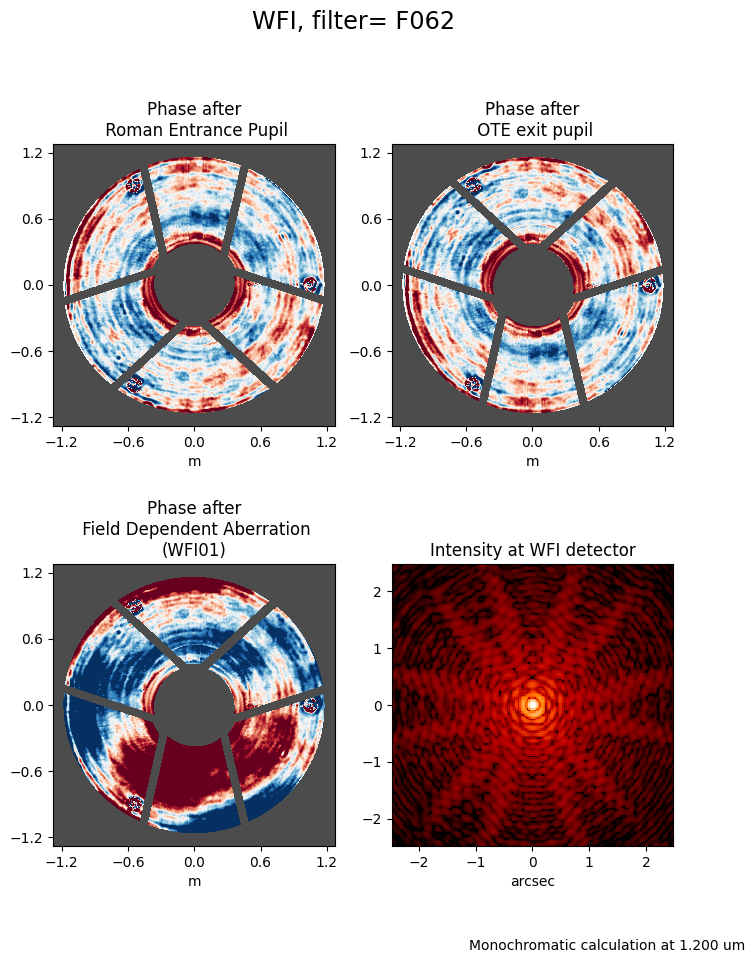

In [4]:
plt.figure(figsize=(8,10))

mono_psf = wfi.calc_psf(monochromatic=1.2e-6, display=True)

The above command shows a plot with four panels (counting left-to-right, top-to-bottom) representing the optical planes in the model:

  1. The entrance pupil transmission in black and white, and the phase ranging from red to blue to show the wavefront error. We include here a plausible estimate for wavefront error due to mirror polishing variations. (This is currently approximated by a map of high-frequency errors in the Hubble primary, since such data is not yet available for the Roman primary mirror.)
  2. The exit pupil, showing the same data but with a change in coordinate system due to passing through focus. This is the pupil orientation as seen by the WFI looking outwards at the sky. 
  3. The same transmission and phase map with the addition of the phase term due to field-dependent optical aberrations and intermediate instrument optics. (Specifically, this is based on Zernike coefficients derived from the Cycle 5 optical modeling effort at GSFC.)
  4. The final oversampled detector plane, with log-scaled intensity


### Using Utility Functions

Now you have the calculation result in the `mono_psf` variable, and can use various utility functions in STPSF to analyze it. The FITS object has an extension called `OVERSAMP` with each pixel split according to the default oversampling factor (4), and an extension called `DET_SAMP` with that image binned down to detector pixels.

In [5]:
mono_psf.info()

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  OVERSAMP      1 PrimaryHDU      53   (184, 184)   float64   
  1  DET_SAMP      1 ImageHDU        55   (46, 46)   float64   
  2  OVERDIST      1 ImageHDU        57   (184, 184)   float64   
  3  DET_DIST      1 ImageHDU        58   (46, 46)   float64   


Let's plot the PSF in detector pixels:

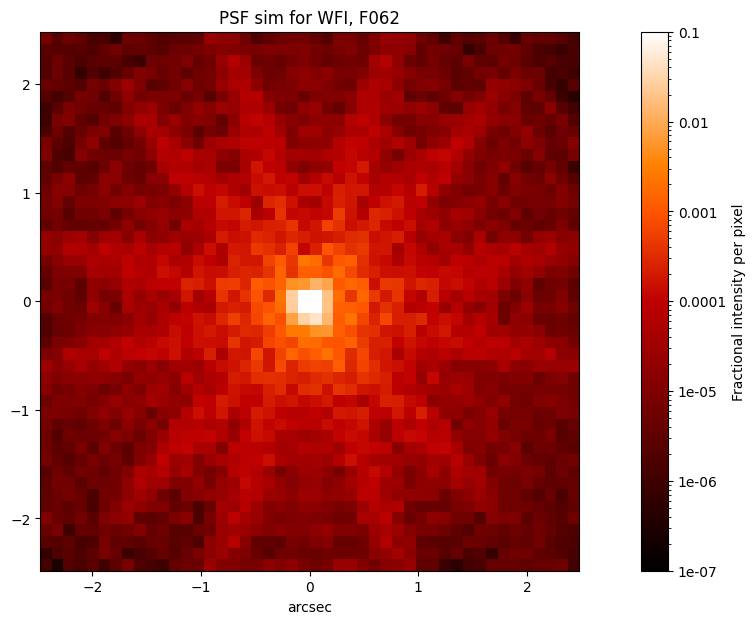

In [6]:
stpsf.display_psf(mono_psf, ext='DET_SAMP')

STPSF also includes functions for measuring EE, profiles, and centroids (described in the [STPSF documentation](http://pythonhosted.org/stpsf/api_reference.html#functions) and the [POPPY documentation](http://pythonhosted.org/poppy/api.html#functions)). Below we measure the radial profile and encircled energy curve for the monochromatic PSF. (Note that the FWHM is also computed and labeled on the radial profile plot.)

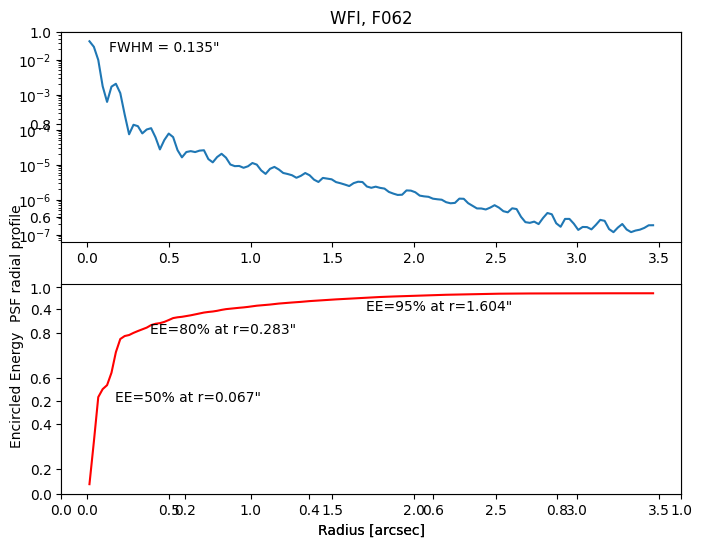

In [7]:
plt.figure(figsize=(8, 6))
stpsf.display_profiles(mono_psf)

If you want, the FITS object containing the PSF can be written out to a file and downloaded to your computer. This can be useful if you need it as an input to another tool.

In [8]:
mono_psf.writeto('./mono_psf_1.2um.fits', overwrite=True)

[astroquery] VerifyWarning: Card is too long, comment will be truncated.


After you run the previous cell, this link will take you to download the FITS image: <a href="files/mono_psf_1.2um.fits">Download mono_psf_1.2um.fits</a>

How that works is a little tricky: when you write `./mono_psf_1.2um.fits`, you're saying you want to save the file in the current working directory for the *Python* process. If you're working locally, that's just the directory where you started the `jupyter notebook` command. If you're working on a remote server, files saved from the notebook will be available at the URL `files/your_filename.fits` relative to this page.

For example, if you're viewing this notebook at `https://example.com/user/janedoe/notebooks/STPSF-Roman_Tutorial.ipynb`, your file will be at `https://example.com/user/janedoe/notebooks/`**files/mono_psf_1.2um.fits**.

## Some more options

Find a list of available WFI filters like so:

In [9]:
wfi.filter_list

[np.str_('F062'),
 np.str_('F087'),
 np.str_('F106'),
 np.str_('F129'),
 np.str_('F146'),
 np.str_('F158'),
 np.str_('F184'),
 np.str_('PRISM'),
 np.str_('F213'),
 np.str_('GRISM0'),
 np.str_('GRISM1')]

[  stpsf] Using pupil mask 'F062' and detector 'WFI01'.
[  stpsf] Using pupil mask 'GRISM1' and detector 'WFI01'.
[  stpsf] Using pupil mask 'GRISM1' and detector 'WFI14'.
[  poppy] No source spectrum supplied, therefore defaulting to 5700 K blackbody
[  poppy] Computing wavelength weights using synthetic photometry for GRISM1...
[  stpsf] Using pupil mask 'GRISM1' and detector 'WFI14'.
[  poppy] PSF calc using fov_arcsec = 5.000000, oversample = 4, number of wavelengths = 10
[  stpsf] Creating optical system model:
[  poppy] Initialized OpticalSystem: Roman+WFI
[  poppy] Roman Entrance Pupil: Loaded amplitude transmission from /Users/jotor/stpsf-data-cyc10/WFI/pupils/RST_WSM_GRISM_grism_WFI14.fits.gz
[  poppy] Roman Entrance Pupil: Loaded OPD from /Users/jotor/stpsf-data-cyc10/upscaled_HST_OPD.fits
[  poppy] Added pupil plane: Roman Entrance Pupil
[  poppy] Added coordinate inversion plane: OTE exit pupil
[  poppy] Added pupil plane: Field Dependent Aberration (WFI14)
[  poppy] Added 

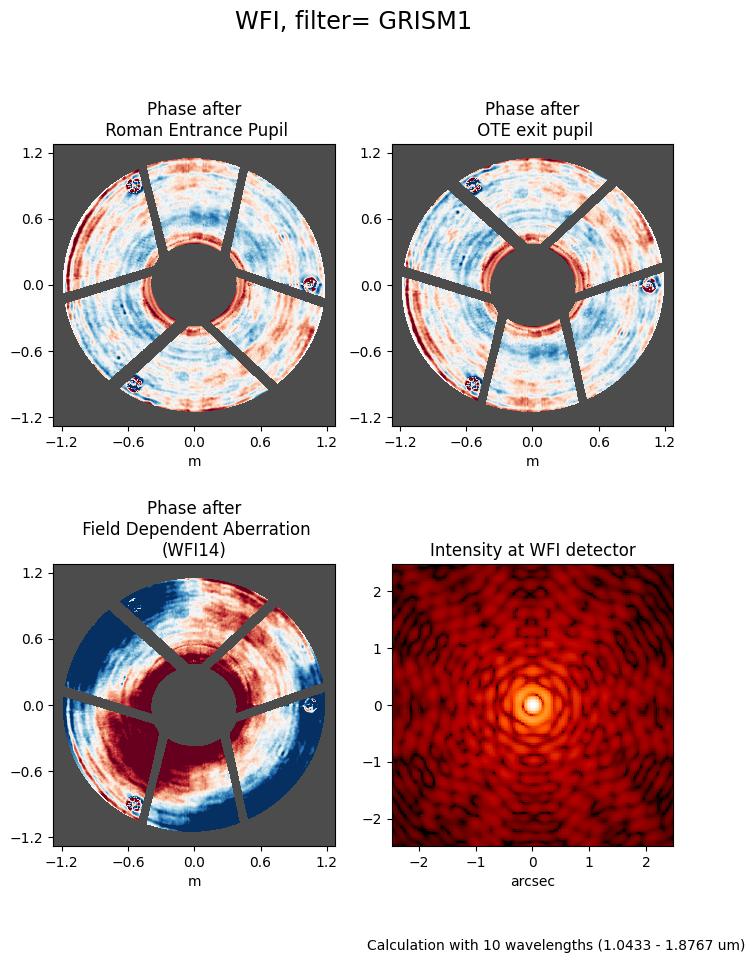

In [10]:
wfi = stpsf.roman.WFI()

wfi.filter = 'GRISM1'
wfi.detector = 'WFI14'

plt.figure(figsize=(8,10))
poly_psf =  wfi.calc_psf(nlambda=10, display=True)

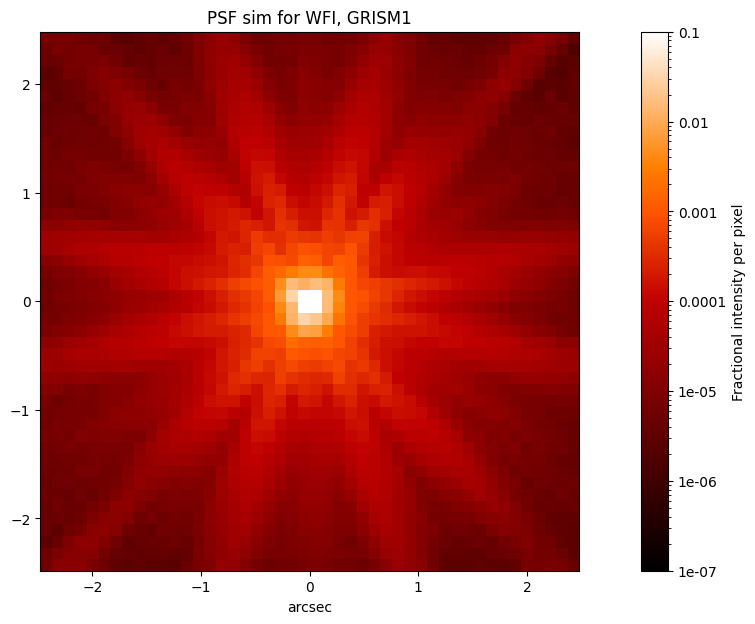

In [11]:
stpsf.display_psf(poly_psf, ext='DET_SAMP')

### WFI Spectroscopic Filters
We showed how simple it is to generate a PSF using the prism or grism filters. However, STPSF does not model the spectral dispersion of these spectroscopic modes. The users are encouraged to generate multiple monochromatic PSF and assemble them into spectra using other tools (e.g. aXe).  

Here, we show how the `datacube()` function can be used to generate multiple monochromatic PSFs and return it in a 3D array.

Find more information on this function [in the STPSF documentation.](https://stpsf.readthedocs.io/en/latest/api/stpsf.JWInstrument.html#stpsf.JWInstrument.calc_datacube_fast)


In [12]:
wfi = stpsf.WFI()

wfi.filter = 'PRISM'

nwaves = 10 
wavelengths = np.linspace(0.75, 1.8, nwaves) * 1e-6

fov_arcsec = 2.5

cube = wfi.calc_datacube(wavelengths, fov_arcsec=fov_arcsec)

[  stpsf] Using pupil mask 'F062' and detector 'WFI01'.
[  stpsf] Using pupil mask 'PRISM' and detector 'WFI01'.
[  poppy] Starting multiwavelength data cube calculation.
[  poppy] Monochromatic calculation requested.
[  stpsf] Using pupil mask 'PRISM' and detector 'WFI01'.
[  poppy] PSF calc using fov_arcsec = 2.500000, oversample = 4, number of wavelengths = 1
[  stpsf] Creating optical system model:
[  poppy] Initialized OpticalSystem: Roman+WFI
[  poppy] Roman Entrance Pupil: Loaded amplitude transmission from /Users/jotor/stpsf-data-cyc10/WFI/pupils/RST_WSM_PRISM_prism_WFI01.fits.gz
[  poppy] Roman Entrance Pupil: Loaded OPD from /Users/jotor/stpsf-data-cyc10/upscaled_HST_OPD.fits
[  poppy] Added pupil plane: Roman Entrance Pupil
[  poppy] Added coordinate inversion plane: OTE exit pupil
[  poppy] Added pupil plane: Field Dependent Aberration (WFI01)
[  poppy] Added detector with pixelscale=0.1078577405 and oversampling=4: WFI detector
[  poppy] Calculating PSF with 1 wavelengths


In [13]:
cube.info()

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  OVERSAMP      1 PrimaryHDU     190   (92, 92, 10)   float64   
  1  DET_SAMP      1 ImageHDU       192   (23, 23, 10)   float64   
  2  OVERDIST      1 ImageHDU       203   (92, 92, 10)   float64   
  3  DET_DIST      1 ImageHDU       204   (23, 23, 10)   float64   


Text(0.5, 0.98, 'PRISM')

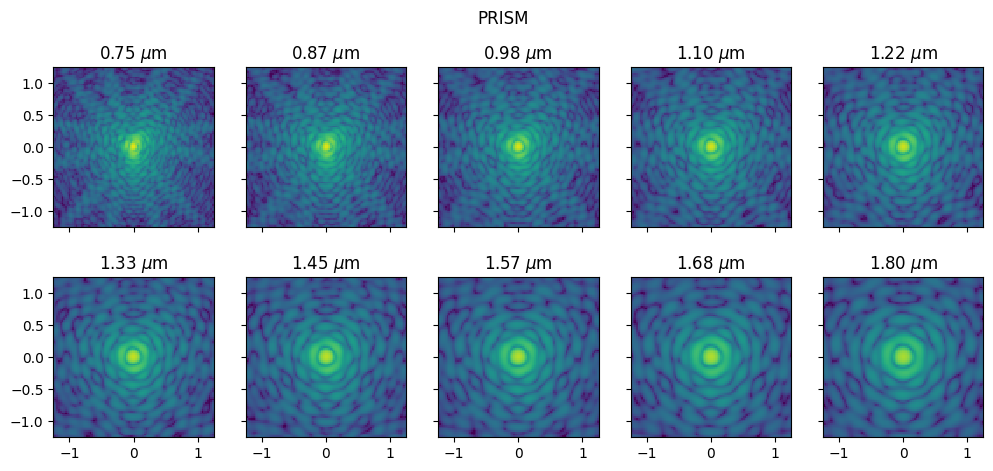

In [14]:
data = cube[0].data

ncols = 5
nrows = int(np.ceil(nwaves/ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5), sharey=True, sharex=True)

axes = axes.flatten()

for i in range(nwaves):
    axes[i].imshow(data[i], norm=LogNorm(vmin=1e-7, vmax=1e-1), 
                   extent=[-fov_arcsec/2, fov_arcsec/2, -fov_arcsec/2, fov_arcsec/2],
                   origin='lower')

    title = "{:4.2f} $\mu$m".format(wavelengths[i]*1e6)
    axes[i].set_title(title)

fig.suptitle(wfi.filter)

# What next?

Keep working in this notebook, if you like! For reference, there's always a [pristine copy of this notebook](https://github.com/spacetelescope/stpsf/blob/master/notebooks/STPSF-Roman_Tutorial.ipynb) to refer back to in the  [STPSF GitHub repository](https://github.com/spacetelescope/stpsf).  If you have not previously used this notebook interface to Python, the Help menu available above has a tutorial and a useful list of keyboard shortcuts. 

  * **Review the [STPSF documentation](https://pythonhosted.org/stpsf/) and the [POPPY documentation](https://pythonhosted.org/poppy/)**
  * **Report any issues to us on GitHub** — 
    STPSF and POPPY are developed on GitHub: [spacetelescope/stpsf](https://github.com/spacetelescope/stpsf) and [spacetelescope/poppy](https://github.com/spacetelescope/poppy) respectively.
    The best way to report bugs is through the GitHub issue trackers: [STPSF](https://github.com/spacetelescope/stpsf/issues) or [POPPY](https://github.com/spacetelescope/poppy/issues). (We also welcome pull requests from the community, if there's functionality you think should be included!)
  * **Contact us through the STScI helpdesk** — You can always email your questions to <a href="mailto:help@stsci.edu">help@stsci.edu</a>, and our helpdesk people will make sure your request gets to the right person
  * **Sign up for STPSF update announcements** —
    This is entirely optional, but you may wish to sign up to the mailing list stpsf-users@stsci.edu. This is a low-traffic moderated announce-only list, to which we will periodically post announcements of updates to this software. To subscribe, visit the [maillist.stsci.edu](http://maillist.stsci.edu) server